# Diagnóstico de Câncer de Mama — CNN com Transfer Learning

Classificação binária de mamografias ROI recortadas do dataset CBIS-DDSM.

- **Entrada**: imagens JPEG de regiões de interesse (crops de massa)
- **Saída**: BENIGNO (0) ou MALIGNO (1)
- **Arquitetura**: MobileNetV2 (transfer learning, fine-tuning parcial)
- **Dados**: 100 treino + 100 teste (gerados por `copy_sample.py`)

## Preparacao do Dataset

Antes de executar este notebook, siga os passos abaixo:

## 1. Baixe o dataset CBIS-DDSM no Kaggle

Acesse e faca o download do arquivo ZIP:
> https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset

Em seguida extraia as pastas csv e jpeg para /data/cnn-data

## 2. Execute o script de amostragem 
Caso não queira usar o dataset inteiro você pode executa o script copy_sample.py antes disso abra o arquivo e configure a variavel SOURCE_DIR com o caminho absoluto do diretorio como o dataset extraido.

você também pode ajustar a quantidade de amostras alterando a variavel SAMPLE_PER_CLASS


Configure  em  com o caminho onde extraiu o ZIP, depois execute:
python copy_sample.py


O script cria automaticamente a estrutura abaixo dentro do projeto:
/data/cnn-data/csv
/data/cnn-data/jpeg
/data/cnn-data/jpeg/{id}/{name}.jpeg




## 1. Configuração de diretorio do dataset

Aqui é feita toda a configuração de Path até o diretorio onde contém a amostra de dados que usaremos para treinar o modelo, se seguiu o passo de preparação do dataset não vai precisar alterar nada aqui.

In [16]:
import os
import warnings
warnings.filterwarnings("ignore")

# Caminhos — ajuste BASE_DIR se rodar fora da pasta TechChallengeA
BASE_DIR     = os.path.abspath(".")
DATASET_DIR  = os.path.join(BASE_DIR, "data","cnn-data")
CSV_DIR      = os.path.join(DATASET_DIR, "csv")
TRAIN_CSV    = os.path.join(CSV_DIR, "train_sample.csv")
TEST_CSV     = os.path.join(CSV_DIR, "test_sample.csv")

# Hiperparâmetros
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 16
EPOCHS_HEAD  = 5    # treina só o topo (camadas densas)
EPOCHS_FINE  = 5    # fine-tuning: descongela últimas camadas do backbone
RANDOM_SEED  = 42

print(f"BASE_DIR  : {BASE_DIR}")
print(f"TRAIN_CSV : {TRAIN_CSV}  | existe={os.path.exists(TRAIN_CSV)}")
print(f"TEST_CSV  : {TEST_CSV}   | existe={os.path.exists(TEST_CSV)}")

BASE_DIR  : c:\Users\clayt\Documents\pessoal\FIAP\POSTECH\FASE1\TechChallenge\TechChallengeA
TRAIN_CSV : c:\Users\clayt\Documents\pessoal\FIAP\POSTECH\FASE1\TechChallenge\TechChallengeA\data\cnn-data\csv\train_sample.csv  | existe=True
TEST_CSV  : c:\Users\clayt\Documents\pessoal\FIAP\POSTECH\FASE1\TechChallenge\TechChallengeA\data\cnn-data\csv\test_sample.csv   | existe=True


## 2. Carregamento e Exploração dos Dados

Nesta etapa carrego os dados de treino e teste do dataset tratamos a coluna de classificação e em seguida plotamos um grafico de barras vertical com os dados de distribuição.

Treino : 100 imagens
Teste  : 100 imagens

Distribuição treino:
class
BENIGNO    50
MALIGNO    50
Name: count, dtype: int64

Distribuição teste:
class
BENIGNO    50
MALIGNO    50
Name: count, dtype: int64


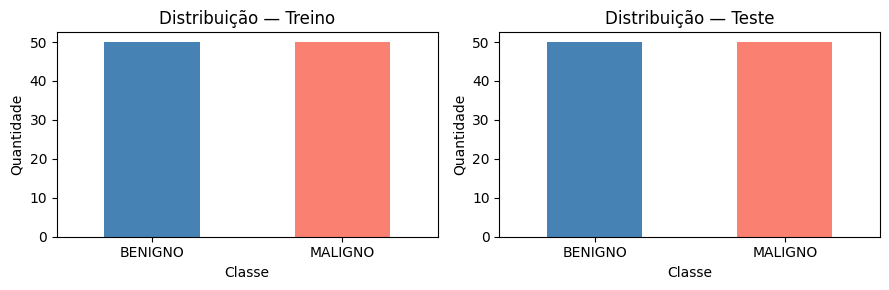

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# Validações básicas
assert "jpeg_path" in train_df.columns, "Coluna 'jpeg_path' ausente. Execute copy_sample.py ou baixe o dataset CBIS-DDSM e extraia na pasta ./data/cnn-data."
assert "label"     in train_df.columns, "Coluna 'label' ausente."

# Constrói path absoluto a partir do jpeg_path relativo
for df in (train_df, test_df):
    df["image_path"] = df["jpeg_path"].apply(
        lambda p: os.path.join(DATASET_DIR, p) if pd.notna(p) else None
    )
    df["class"] = df["label"].map({0: "BENIGNO", 1: "MALIGNO"})

# Mantém apenas arquivos existentes no disco
train_df = train_df[train_df["image_path"].apply(os.path.exists)].reset_index(drop=True)
test_df  = test_df[test_df["image_path"].apply(os.path.exists)].reset_index(drop=True)

print(f"Treino : {len(train_df)} imagens")
print(f"Teste  : {len(test_df)} imagens")
print(f"\nDistribuição treino:\n{train_df['class'].value_counts()}")
print(f"\nDistribuição teste:\n{test_df['class'].value_counts()}")

# Gráfico de distribuição
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, (df, title) in zip(axes, [(train_df, "Treino"), (test_df, "Teste")]):
    df["class"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "salmon"])
    ax.set_title(f"Distribuição — {title}")
    ax.set_xlabel("Classe")
    ax.set_ylabel("Quantidade")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

Agora é feita a exibição de  algumas images da amostra para analise prévia.

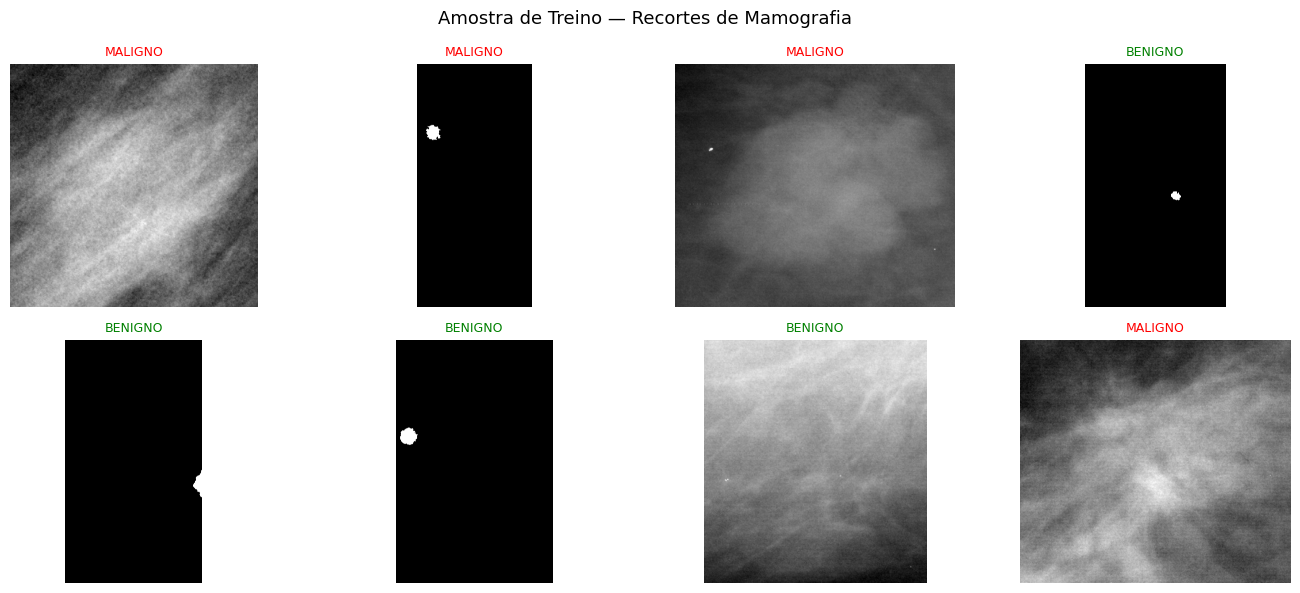

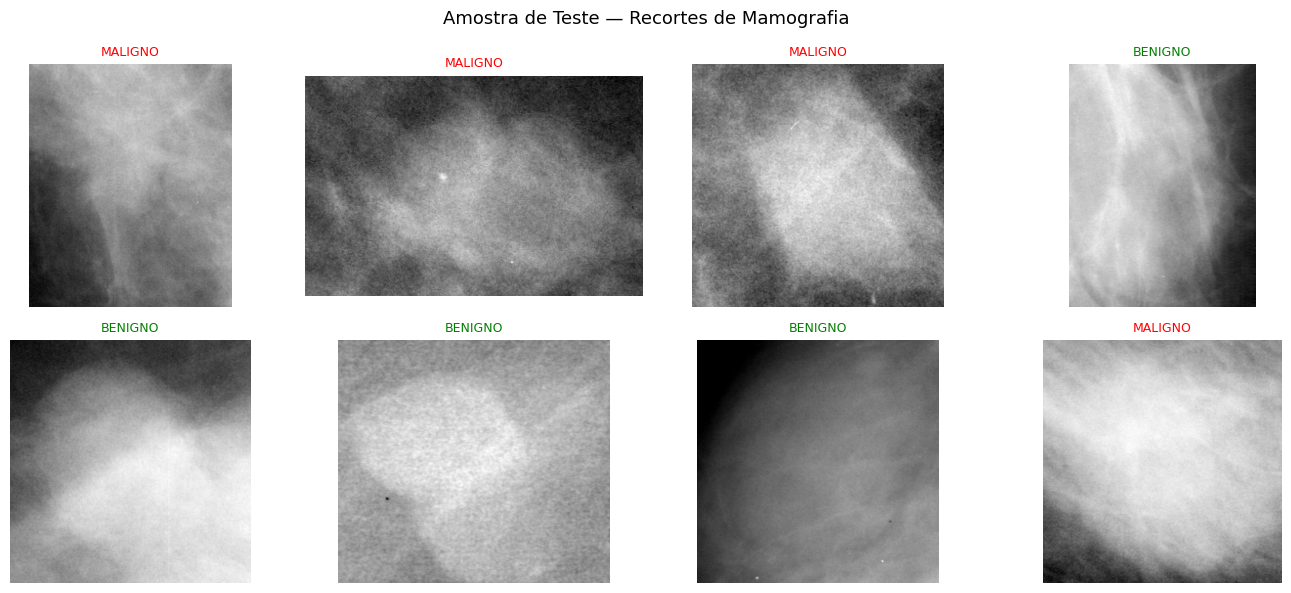

In [18]:
from PIL import Image
import numpy as np

def show_sample_images(df, n=8, title=""):
    sample = df.sample(min(n, len(df)), random_state=RANDOM_SEED)
    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        try:
            img = Image.open(row["image_path"]).convert("RGB")
            ax.imshow(np.array(img))
            color = "red" if row["label"] == 1 else "green"
            ax.set_title(row["class"], color=color, fontsize=9)
        except Exception as e:
            ax.set_title(f"Erro", fontsize=7)
        ax.axis("off")
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

show_sample_images(train_df, title="Amostra de Treino — Recortes de Mamografia")
show_sample_images(test_df,  title="Amostra de Teste — Recortes de Mamografia")

## 3. Geradores de Imagens (Data Augmentation)

Aqui novamente eu uso o stratify para garantir a disstribuição entre malignos e benignos antes de cria variações artificiais das imagens de treino para o modelo não memorizar os exemplos e generalizar melhor. Validação e teste só fazem o rescale, sem augmentation.

O flow_from_dataframe crie um gerador que lê as imagens do disco em lotes (batch_size=16), redimensiona para 224×224 e entrega já prontas para o modelo — sem precisar carregar tudo na memória de uma vez.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

print(f"TensorFlow {tf.__version__}")

# Split treino / validação (80/20)
train_split, test_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=RANDOM_SEED,
)

print(f"Treino    : {len(train_split)}")
print(f"Validação : {len(test_split)}")
print(f"Teste     : {len(test_df)}")

# Augmentação apenas no treino
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
)
base_datagen = ImageDataGenerator(rescale=1.0 / 255)

def make_gen(datagen, df, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=df,
        x_col="image_path",
        y_col="class",
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=["BENIGNO", "MALIGNO"],
        shuffle=shuffle,
        seed=RANDOM_SEED,
    )

train_gen = make_gen(train_datagen, train_split, shuffle=True)
val_gen   = make_gen(base_datagen,  test_split,   shuffle=False)
test_gen  = make_gen(base_datagen,  test_df,     shuffle=False)

print(f"\nMapa de classes: {train_gen.class_indices}")
print(f"Steps por época (treino): {len(train_gen)}")

TensorFlow 2.21.0
Treino    : 80
Validação : 20
Teste     : 100
Found 80 validated image filenames belonging to 2 classes.
Found 20 validated image filenames belonging to 2 classes.
Found 100 validated image filenames belonging to 2 classes.

Mapa de classes: {'BENIGNO': 0, 'MALIGNO': 1}
Steps por época (treino): 5


## 4. Construção do Modelo — MobileNetV2 + Cabeçalho Customizado

A compilação é feita nesta fase após utillizar tecnica de congelamento de camadas e usso de cabeçalho customizado ainda estou estudando estas camadas não entendo muito bem oque cada uma delas faz.

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

def build_model(image_size, trainable_base=False):
    backbone = MobileNetV2(
        input_shape=(*image_size, 3),
        include_top=False,
        weights="imagenet",
    )
    backbone.trainable = trainable_base

    model = models.Sequential([
        backbone,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ], name="cnn_mama")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

model = build_model(IMAGE_SIZE, trainable_base=False)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "cnn_mama"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 5. Fase 1 — Treino do Cabeçalho (backbone congelado)

Nesta etapa executo o treinamento em duas fases:  Fase 1 treino rápido, cabeçalho aprende as features sem bagunçar o backbone
Risco se pular: pesos aleatórios do cabeçalho podem "destruir" os pesos do backbone logo no início

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks_head = [
    EarlyStopping(monitor="val_auc", patience=3, restore_best_weights=True, mode="max"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_head,
    verbose=1,
)

print(f"\nMelhor val_auc (fase 1): {max(history_head.history['val_auc']):.4f}")

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4250 - auc: 0.4291 - loss: 1.2217 - val_accuracy: 0.5000 - val_auc: 0.4200 - val_loss: 0.8485 - learning_rate: 0.0010
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 893ms/step - accuracy: 0.4750 - auc: 0.5494 - loss: 0.9843 - val_accuracy: 0.5000 - val_auc: 0.4350 - val_loss: 0.9590 - learning_rate: 0.0010
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.7044 - auc: 0.7321 - loss: 0.6577
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 887ms/step - accuracy: 0.7250 - auc: 0.7819 - loss: 0.6101 - val_accuracy: 0.5000 - val_auc: 0.5100 - val_loss: 1.1300 - learning_rate: 0.0010
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 905ms/step - accuracy: 0.7250 - auc: 0.7950 - loss: 0.5998 - val_accuracy: 0.5000 - val_auc: 0.5200 - val_loss: 1.1534 - learning_rate: 5.0000e-04
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.6398 - auc: 0.6663 - loss: 0.6835
Epoch 5: Reduc

## 6. Fase 2 — Fine-Tuning (descongela últimas 30 camadas do backbone)

fase2: O backbone ajusta suas features para o domínio específico de mamografias
  Requer lr menor (1e-4) para não sobrescrever o que o backbone já aprendeu

In [7]:
# Descongela as últimas 30 camadas do MobileNetV2
backbone = model.layers[0]
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

# Recompila com learning rate menor
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

callbacks_fine = [
    EarlyStopping(monitor="val_auc", patience=3, restore_best_weights=True, mode="max"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=callbacks_fine,
    verbose=1,
)

print(f"\nMelhor val_auc (fase 2): {max(history_fine.history['val_auc']):.4f}")

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5375 - auc: 0.5641 - loss: 0.9282 - val_accuracy: 0.5000 - val_auc: 0.4900 - val_loss: 1.0136 - learning_rate: 1.0000e-04
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 972ms/step - accuracy: 0.7125 - auc: 0.7663 - loss: 0.6435 - val_accuracy: 0.4500 - val_auc: 0.5100 - val_loss: 0.9623 - learning_rate: 1.0000e-04
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 991ms/step - accuracy: 0.7125 - auc: 0.8094 - loss: 0.5508 - val_accuracy: 0.5000 - val_auc: 0.5250 - val_loss: 1.0614 - learning_rate: 1.0000e-04
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.6552 - auc: 0.7778 - loss: 0.6000
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 973ms/step - accuracy: 0.6875 - auc: 0.8213 - loss: 0.5327 - val_accuracy: 0.4500 - val_auc: 0.5100 - val_loss: 1.0540 - learning_rate: 1.0000e-04
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 990ms/step - accuracy: 0.7250 - auc: 0.8284 - loss: 0.5713 - 

## 7. Curvas de Aprendizado

Os históricos das duas fases são concatenados — você vê o treino completo em sequência, com uma linha cinza tracejada marcando onde a Fase 1 termina e a Fase 2 começa.

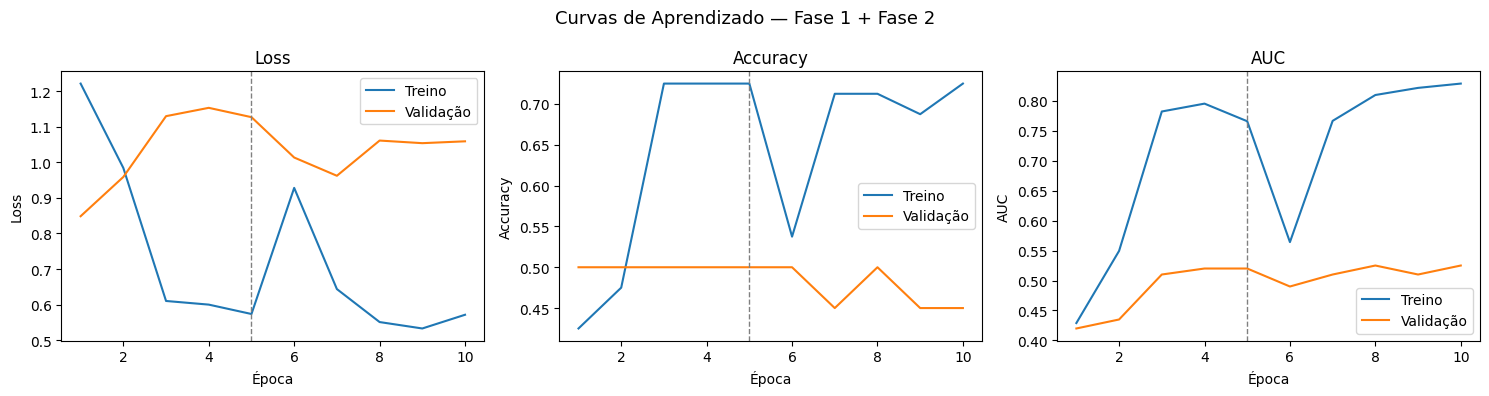

In [8]:
def plot_history(histories, labels):
    """Plota loss, accuracy e AUC para uma ou mais fases de treino."""
    # Concatena históricos
    combined = {k: [] for k in histories[0].history}
    for h in histories:
        for k, v in h.history.items():
            combined[k].extend(v)

    epochs = range(1, len(combined["loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, (metric, val_metric, ylabel) in zip(axes, [
        ("loss",     "val_loss",     "Loss"),
        ("accuracy", "val_accuracy", "Accuracy"),
        ("auc",      "val_auc",      "AUC"),
    ]):
        ax.plot(epochs, combined[metric],     label="Treino")
        ax.plot(epochs, combined[val_metric], label="Validação")
        ax.set_xlabel("Época")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend()

    # Linha divisória entre fase 1 e fase 2
    n1 = len(histories[0].history["loss"])
    for ax in axes:
        ax.axvline(x=n1, color="gray", linestyle="--", linewidth=1, label="Fine-tune")

    plt.suptitle("Curvas de Aprendizado — Fase 1 + Fase 2", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history([history_head, history_fine], ["Cabeçalho", "Fine-Tuning"])

## 8. Avaliação no Conjunto de Teste

Aqui novamente eu uso o classification_report juntamente com confusion_matrix pois a exibição de das metricas de f1-score e re-call são importantes para o nosso contexto de treinameento.

AUC-ROC  : 0.5748

Relatório de classificação:
              precision    recall  f1-score   support

     BENIGNO       1.00      0.02      0.04        50
     MALIGNO       0.51      1.00      0.67        50

    accuracy                           0.51       100
   macro avg       0.75      0.51      0.36       100
weighted avg       0.75      0.51      0.36       100



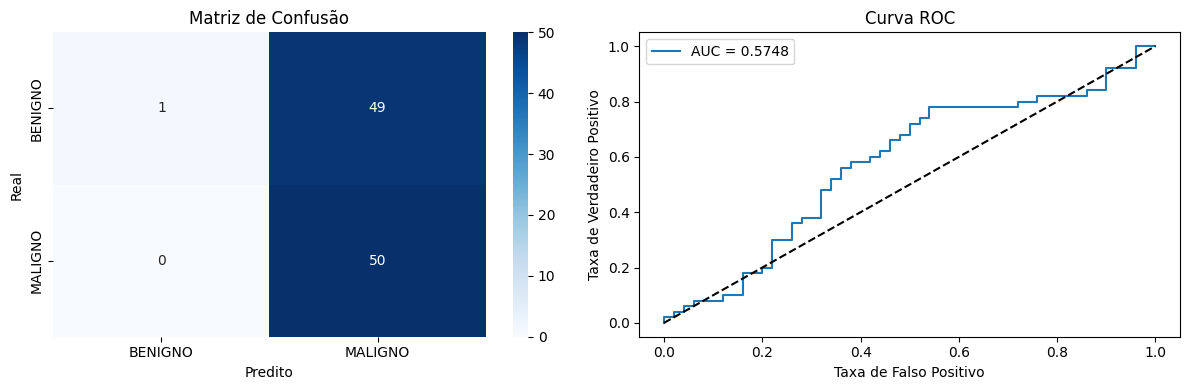

In [9]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import seaborn as sns

# Predições
test_gen.reset()
y_prob = model.predict(test_gen, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

# Métricas
auc_score = roc_auc_score(y_true, y_prob)
print(f"AUC-ROC  : {auc_score:.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_true, y_pred, target_names=["BENIGNO", "MALIGNO"]))

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["BENIGNO", "MALIGNO"],
    yticklabels=["BENIGNO", "MALIGNO"],
    ax=axes[0]
)
axes[0].set_title("Matriz de Confusão")
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")

# Curva ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("Taxa de Falso Positivo")
axes[1].set_ylabel("Taxa de Verdadeiro Positivo")
axes[1].set_title("Curva ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Visualização das Predições


Esta célula mostra o modelo em ação — pega 8 imagens aleatórias do teste e exibe o que o modelo previu versus o que a imagem realmente é.
Permite fazer uma análise visual rápida dos erros do modelo erros em vermelho mostram onde o modelo falhou — útil para entender os limites do modelo antes de partir para o Grad-CAM, que explica o porquê de cada decisão

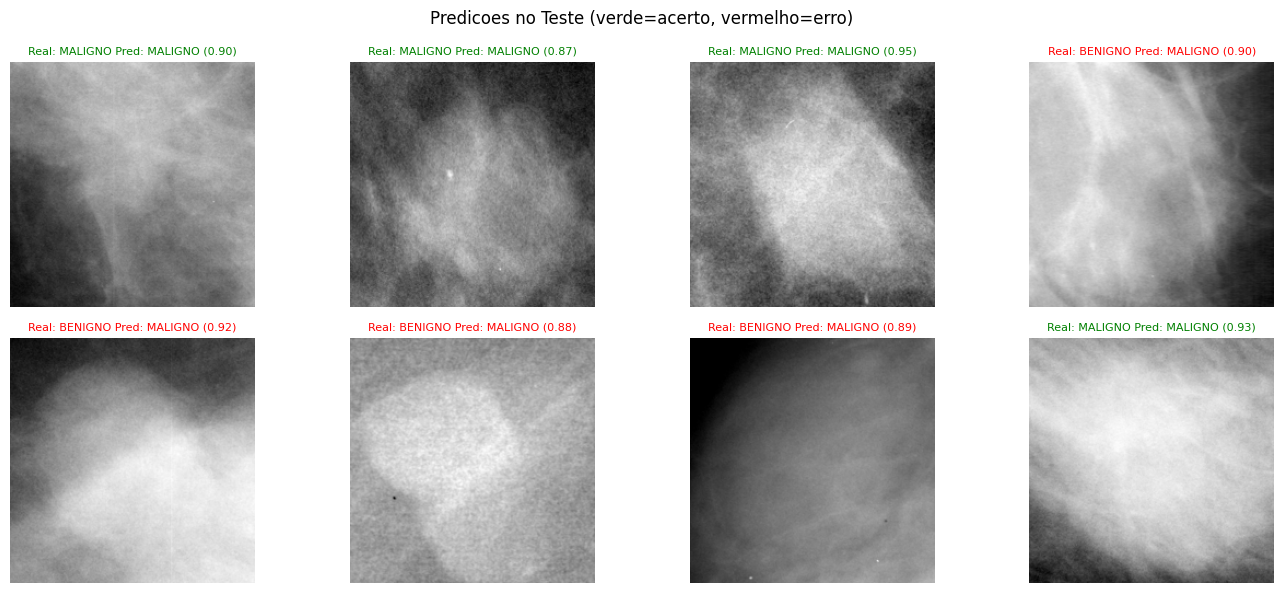

In [19]:
from PIL import Image
import numpy as np

# Amostra de 8 imagens do conjunto de teste
sample = test_df.sample(8, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img  = Image.open(row["image_path"]).convert("RGB").resize(IMAGE_SIZE)
    prob = model.predict(
        np.expand_dims(np.array(img) / 255.0, axis=0), verbose=0
    )[0][0]
    pred = "MALIGNO" if prob >= 0.5 else "BENIGNO"
    real = row["class"]
    cor  = "green" if pred == real else "red"
    ax.imshow(img)
    ax.set_title(
        f"Real: {real} Pred: {pred} ({prob:.2f})",
        color=cor, fontsize=8
    )
    ax.axis("off")

plt.suptitle("Predicoes no Teste (verde=acerto, vermelho=erro)", fontsize=12)
plt.tight_layout()
plt.show()


## 10. Grad-CAM — Visualizacao de Ativacoes


Um modelo que acerta por razões erradas é perigoso. O Grad-CAM permite verificar se o modelo está olhando para a região da massa (correto) ou para artefatos da imagem como bordas ou ruído (incorreto). É uma ferramenta de explicabilidade — fundamental para aplicações clínicas onde a decisão precisa ser justificável. Eu ainda estou aprendendo a Utilizar o Grad-CAM mas achei bem interessante.

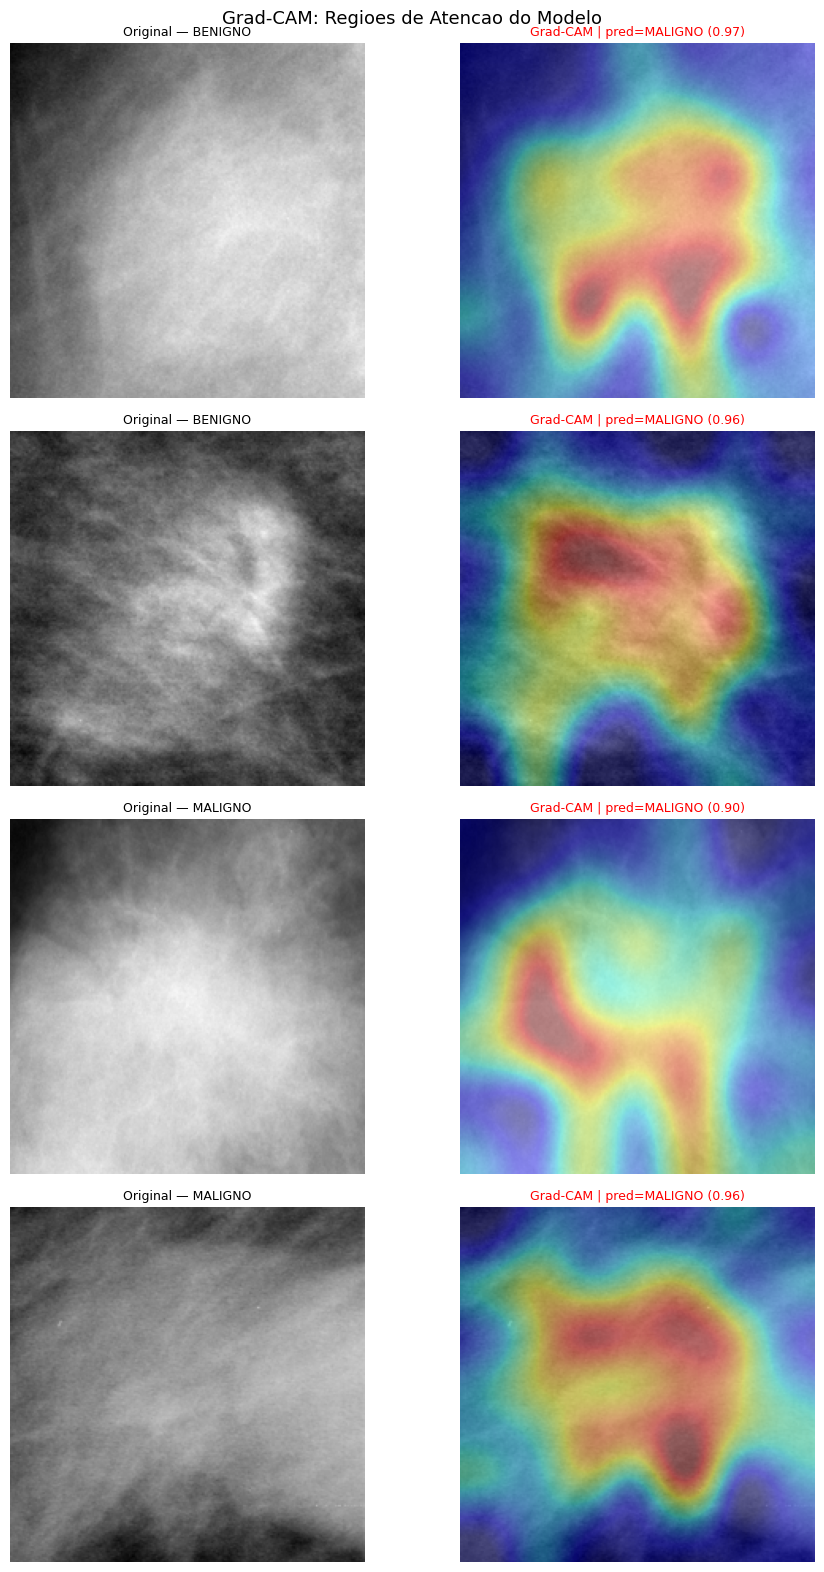

In [13]:
import numpy as np
import matplotlib.cm as cm
import tensorflow as tf
from PIL import Image

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    backbone   = model.layers[0]  # MobileNetV2
    conv_layer = backbone.get_layer(last_conv_layer_name)

    # Sub-modelo: entrada -> ultima camada conv do backbone
    conv_model = tf.keras.models.Model(
        inputs=backbone.inputs, outputs=conv_layer.output
    )

    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        conv_out = conv_model(img_tensor)
        tape.watch(conv_out)
        # Passa pelo restante do Sequential (camadas apos o backbone)
        x = conv_out
        for layer in model.layers[1:]:
            x = layer(x)
        loss = x[:, 0]

    grads   = tape.gradient(loss, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-8)
    return heatmap

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = np.array(Image.open(img_path).convert("RGB").resize(IMAGE_SIZE))
    # Redimensiona heatmap com PIL (sem cv2)
    heat_resized = np.array(
        Image.fromarray(np.uint8(heatmap * 255)).resize(IMAGE_SIZE, Image.LANCZOS)
    ) / 255.0
    # Aplica colormap JET via matplotlib (sem cv2)
    jet = cm.get_cmap("jet")
    heat_rgb = np.uint8(jet(heat_resized)[:, :, :3] * 255)
    return np.uint8(img * (1 - alpha) + heat_rgb * alpha)

LAST_CONV = "out_relu"

sample_rows = pd.concat([
    test_df[test_df["label"] == 0].head(2),
    test_df[test_df["label"] == 1].head(2),
]).reset_index(drop=True)

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(10, 4 * len(sample_rows)))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img_orig = np.array(Image.open(row["image_path"]).convert("RGB").resize(IMAGE_SIZE))
    img_arr  = np.expand_dims(img_orig / 255.0, axis=0).astype(np.float32)

    try:
        heatmap = get_gradcam_heatmap(model, img_arr, LAST_CONV)
        overlay = overlay_gradcam(row["image_path"], heatmap)
    except Exception as e:
        overlay = img_orig
        print(f"Grad-CAM falhou: {e}")

    prob  = model.predict(img_arr, verbose=0)[0][0]
    label = "MALIGNO" if prob >= 0.5 else "BENIGNO"
    color = "red" if label == "MALIGNO" else "green"

    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title(f"Original — {row[chr(99)+chr(108)+chr(97)+chr(115)+chr(115)]}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"Grad-CAM | pred={label} ({prob:.2f})", color=color, fontsize=9)
    axes[i, 1].axis("off")

plt.suptitle("Grad-CAM: Regioes de Atencao do Modelo", fontsize=13)
plt.tight_layout()
plt.show()


## 11. Conclusão

Este notebook demonstra uma pipeline completa de diagnóstico de câncer de mama por imagem:

| Etapa | Detalhe |
|---|---|
| Dataset | CBIS-DDSM — 100 treino / 100 teste (crops de massa balanceados) |
| Backbone | MobileNetV2 pré-treinado em ImageNet |
| Estratégia | 2 fases: (1) treino do cabeçalho, (2) fine-tuning das últimas 30 camadas |
| Augmentação | Rotação, flip horizontal, zoom, shift |
| Métricas | AUC-ROC, Accuracy, Precision, Recall, F1 |
| Explicabilidade | Grad-CAM sobre a camada `out_relu` do MobileNetV2 |

### Limitações
- Amostra pequena (200 imagens); modelos treinados em datasets completos terão desempenho superior.
- Não substitui avaliação médica especializada.
### O que pode ser feito para melhorar
- Ampliar para o dataset CBIS-DDSM completo (~3.000 imagens).
- Comparar com EfficientNetB0 e ResNet50. (Não consegui executar a comparação)